# 7 - Results analysis
We analyze the results from model testing and compare it with the ones from model training. 

### Test results analysis
We analyze the `test_results_dict` in the following aspects:
- Model performance summary
- Rank-based comparison
- Visual heatmap
- Best model counts
- Average performance plot
- Hardest categories

We load the data output from model training and testing.

In [1]:
import pandas as pd

df = pd.read_csv("test_results.csv", index_col=0)
dg = pd.read_csv("cv_results.csv", index_col=0)

# Optionally convert to nested dictionary: category -> model -> score
test_results_dict = df.to_dict(orient="index")  # {category: {model: value}}
cv_results_dict = dg.to_dict(orient="index")  # {model: {category: value}}


📋 Summary Statistics (Normalized RMSE per Model):
                 mean    std    min    max
SARIMA_CV       1.390  0.944  0.000  5.143
EST_CV          1.464  0.975  0.265  4.984
Dummy           1.530  1.013  0.202  5.379
Prophet         1.532  0.961  0.278  5.106
Prophet_Full    1.532  0.961  0.278  5.106
EST_NCV         1.603  1.174  0.272  8.196
Weekday_Linear  2.355  1.698  0.437  7.877

🏆 Average Rank per Model:
EST_CV            2.30
SARIMA_CV         2.62
Prophet           3.47
Prophet_Full      3.47
EST_NCV           3.75
Dummy             4.05
Weekday_Linear    6.32
dtype: float64


/tmp/ipykernel_32463/3151372139.py:30: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/roberto/anaconda3/envs/arxiv-heatmaps/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


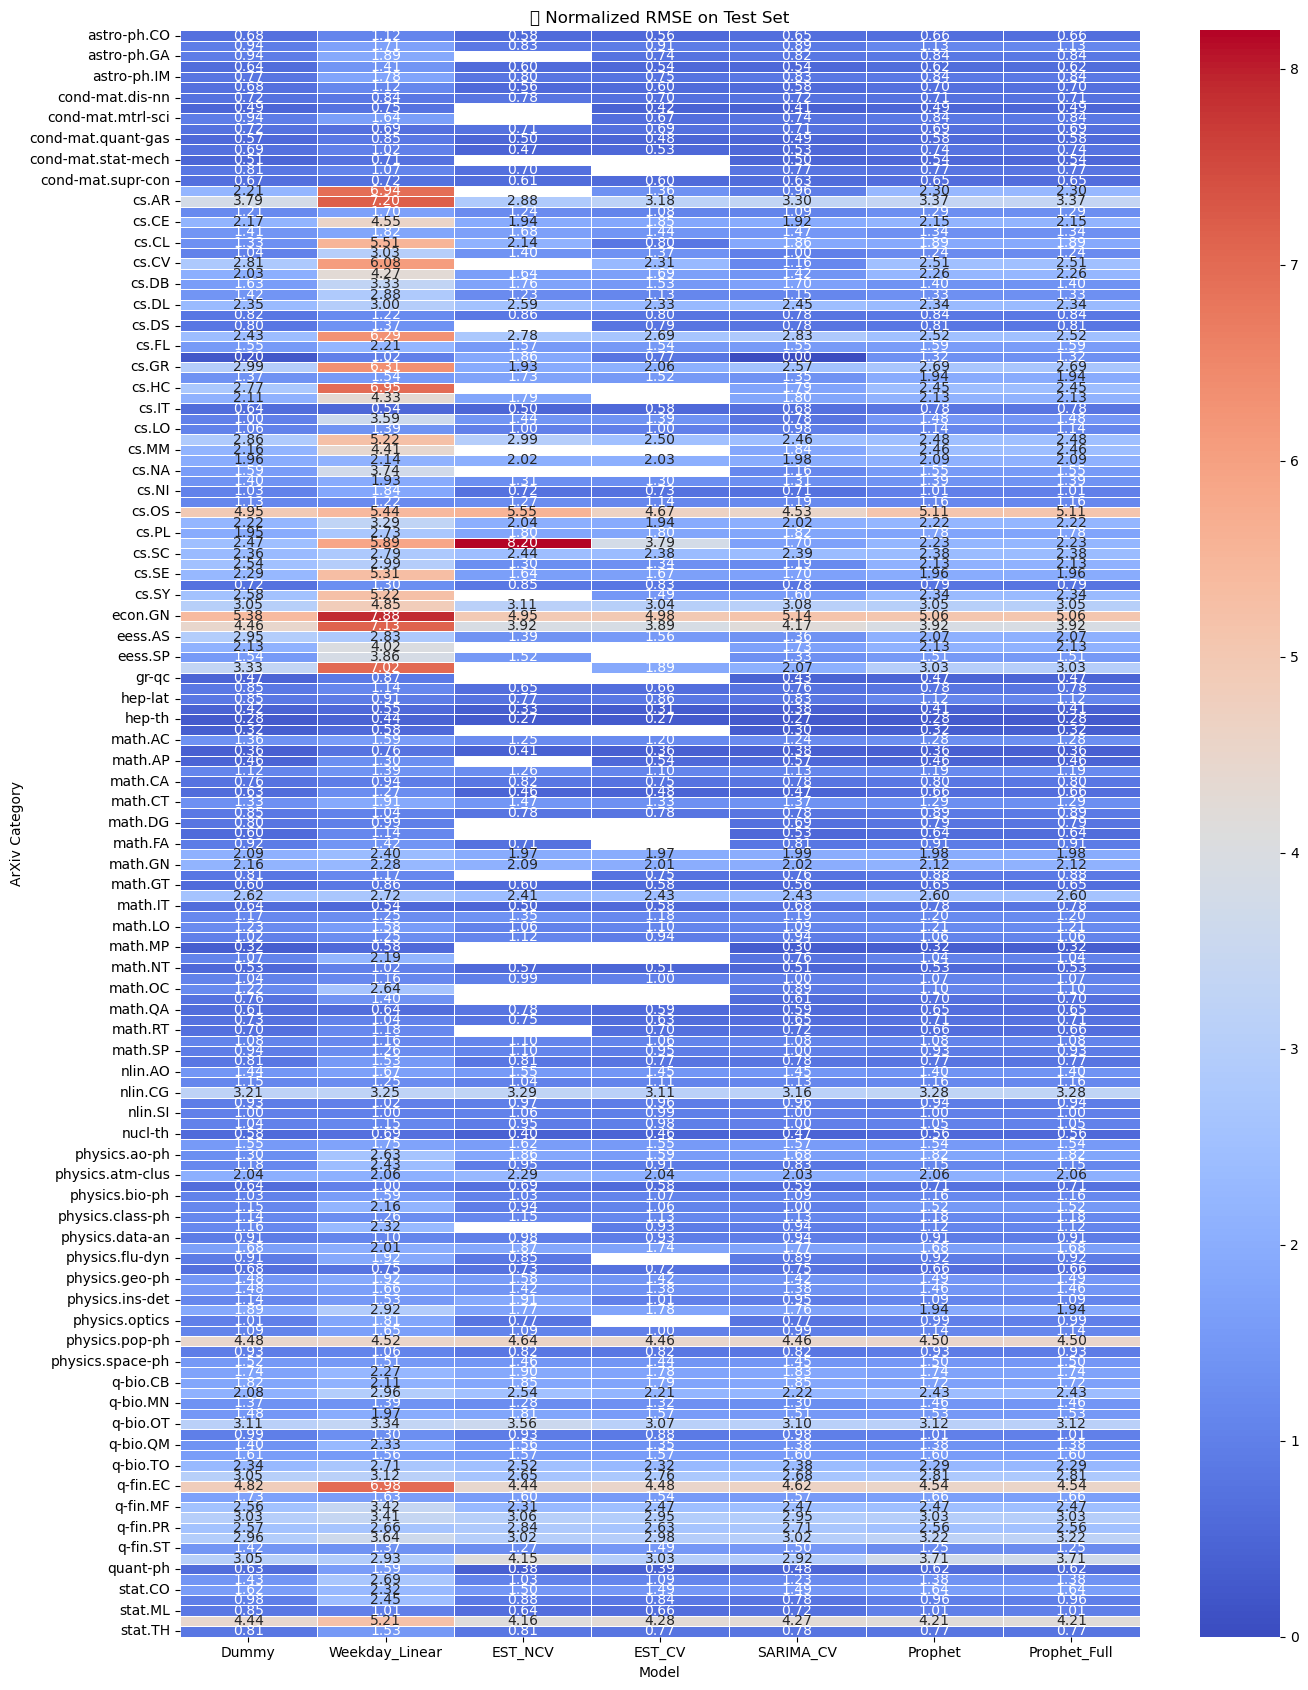


🥇 Best Model Count per Category:
EST_CV            45
SARIMA_CV         44
EST_NCV           33
Prophet           19
Dummy             13
Weekday_Linear     1
Name: count, dtype: int64


/tmp/ipykernel_32463/3151372139.py:45: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/roberto/anaconda3/envs/arxiv-heatmaps/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


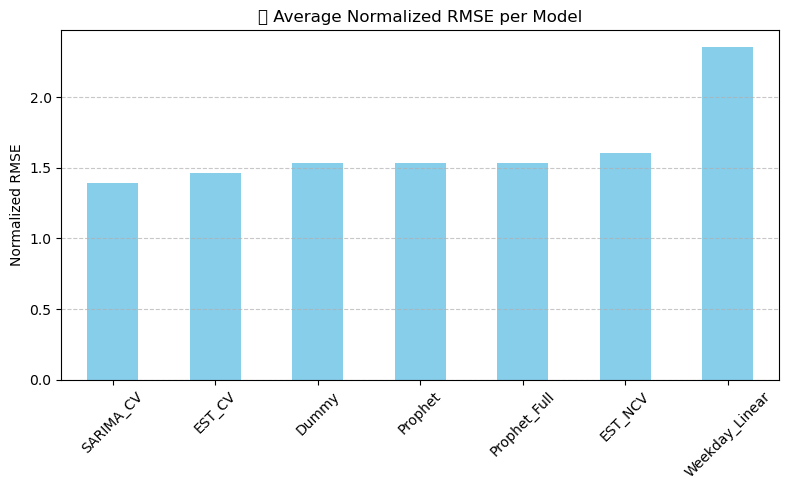


⚠️ Most Challenging Categories (Highest Avg RMSE):
econ.GN           5.493
cs.OS             5.050
q-fin.EC          4.918
physics.pop-ph    4.511
econ.TH           4.487
dtype: float64


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
results_df = pd.DataFrame.from_dict(test_results_dict, orient="index")

# Exclude certain categories from the results
# excluded_categories = ["cs.GL", "cs.OS", "nlin.CG"]
# results_df = results_df[~results_df.index.isin(excluded_categories)]

# 1. Summary Statistics
summary = results_df.describe().T.sort_values("mean")
print("\n📋 Summary Statistics (Normalized RMSE per Model):")
print(summary[["mean", "std", "min", "max"]].round(3))

# 2. Average Rank per Model
ranks = results_df.rank(axis=1, method="min")
average_ranks = ranks.mean().sort_values()
print("\n🏆 Average Rank per Model:")
print(average_ranks.round(2))

# 3. Heatmap of Normalized RMSEs
plt.figure(figsize=(14, 17))
sns.heatmap(results_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("🗺️ Normalized RMSE on Test Set")
plt.xlabel("Model")
plt.ylabel("ArXiv Category")
plt.tight_layout()
plt.show()

# 4. Best Model per Category
best_model_counts = results_df.idxmin(axis=1).value_counts()
print("\n🥇 Best Model Count per Category:")
print(best_model_counts)

# 5. Bar Plot of Average RMSE per Model
plt.figure(figsize=(8, 5))
results_df.mean().sort_values().plot(kind="bar", color="skyblue")
plt.title("📊 Average Normalized RMSE per Model")
plt.ylabel("Normalized RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Most Difficult Categories
difficult_cats = results_df.mean(axis=1).sort_values(ascending=False).head(5)
print("\n⚠️ Most Challenging Categories (Highest Avg RMSE):")
print(difficult_cats.round(3))

# Save results
results_df.to_csv("test_results.csv")
summary.to_csv("test_summary_stats.csv")
ranks.to_csv("test_model_ranks.csv")

### CV results and test results comparison

We compare `cv_results_dict` (from tuning step) and `test_results_dict` (from final evaluation step) side-by-side and focus on the following:

- Test vs CV Mean RMSE: overall generalization performance

- Difference (Test - CV): raw overfitting gap

- Ratio (Test / CV): normalized generalization factor

- Bar Plot: visual model stability


📉 Mean RMSE (CV):
Dummy             1.477
EST_CV            1.390
EST_NCV           1.409
Prophet           1.494
Prophet_Full      1.483
SARIMA_CV         1.403
Weekday_Linear    1.379
dtype: float64

📈 Mean RMSE (Test):
Dummy             1.530
EST_CV            1.464
EST_NCV           1.603
Prophet           1.532
Prophet_Full      1.532
SARIMA_CV         1.390
Weekday_Linear    2.355
dtype: float64

🔍 Difference (Test - CV):
Dummy             0.054
EST_CV            0.010
EST_NCV           0.112
Prophet           0.038
Prophet_Full      0.048
SARIMA_CV        -0.013
Weekday_Linear    0.976
dtype: float64

📊 Ratio (Test / CV):
Dummy             1.04
EST_CV            1.01
EST_NCV           1.06
Prophet           1.03
Prophet_Full      1.05
SARIMA_CV         1.02
Weekday_Linear    1.76
dtype: float64


/tmp/ipykernel_32463/278268264.py:43: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/roberto/anaconda3/envs/arxiv-heatmaps/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


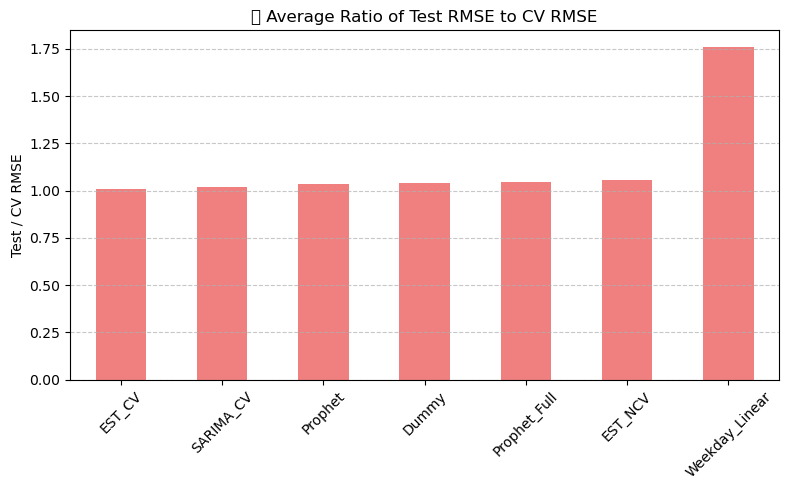

In [3]:
import pandas as pd

# Convert both dicts to DataFrames
cv_df = pd.DataFrame.from_dict(cv_results_dict, orient="index")
test_df = pd.DataFrame.from_dict(test_results_dict, orient="index")

# Align columns and index
cv_df = cv_df.sort_index().sort_index(axis=1)
test_df = test_df.sort_index().sort_index(axis=1)

# Compute comparison metrics
delta_df = test_df - cv_df
ratio_df = test_df / cv_df

# Print key insights
print("\n📉 Mean RMSE (CV):")
print(cv_df.mean().round(3))

print("\n📈 Mean RMSE (Test):")
print(test_df.mean().round(3))

print("\n🔍 Difference (Test - CV):")
print(delta_df.mean().round(3))

print("\n📊 Ratio (Test / CV):")
print(ratio_df.mean().round(2))

# Save to CSVs
cv_df.to_csv("cv_results_aligned.csv")
test_df.to_csv("test_results_aligned.csv")
delta_df.to_csv("delta_test_minus_cv.csv")
ratio_df.to_csv("ratio_test_over_cv.csv")

# Optional: visualize average ratio per model
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ratio_df.mean().sort_values().plot(kind="bar", color="lightcoral")
plt.title("🔍 Average Ratio of Test RMSE to CV RMSE")
plt.ylabel("Test / CV RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

<!-- ### Summary
From the above analysis, we have the following conclusion based on the testing data:
- ✅ Use **SARIMA_CV** as our baseline forecasting model.
- ✅ Keep **EST_CV** as a competitive alternative for faster training and interpretability.
- ⚠️ Use **Prophet** only for interpretability or when domain-specific seasonality is known and controlled.
- ❌ Avoid relying on **Prophet** for performance-sensitive forecasting, especially on sparse or low-signal time series. -->

### Summary
From the above analysis, we have the following conclusion based on the testing data:
- ✅ Use **SARIMA_CV** as our baseline forecasting model for its robust and consistent performance.
- ✅ Keep **EST_CV** as a strong alternative with faster training and competitive accuracy.
- ⚠️ Use **Prophet** (and **Prophet_Full**) cautiously — it performs reasonably in some categories but still shows variability.
- ⚠️ Use **Dummy** as a fallback baseline, especially for stationary or low-variance series.
- ❌ Avoid **EST_NCV** unless optimization is infeasible — its fixed parameters limit performance.
- ❌ Avoid **Weekday_Linear**, as it consistently ranks last and performs poorly across nearly all categories.


<!-- ---

$\star$ Key Metrics (Test Set)

| Model         | Mean RMSE | Std Dev | Min RMSE | Max RMSE |
|---------------|-----------|---------|----------|----------|
| **SARIMA_CV** | **1.35**  | 0.88    | 0.00     | 4.94     |
| **EST_CV**    | 1.46      | 0.95    | 0.27     | 4.82     |
| **Dummy**     | 1.50      | 0.97    | 0.20     | 5.11     |
| **EST_NCV**   | 1.59      | 1.16    | 0.28     | 8.28     |
| **Prophet**   | 6.44      | 19.21   | 0.20     | 230.98   |
| **Prophet_Full** | 6.41   | 19.33   | 0.20     | 232.60   |

---

$\star$ Model Rank Distribution and Recommendations

| Model           | Average Rank | Times Ranked 1st | Times Ranked 2nd | Times Ranked 3rd | Times Ranked 4th | Times Ranked 5th | Times Ranked 6th | Comments                                      | Suggested Use Case                          |
|-----------------|---------------|------------------|------------------|------------------|------------------|------------------|------------------|------------------------------------------------|---------------------------------------------|
| **SARIMA_CV**   | 2.32          | 41               | 44               | 52               | 12               | 5                | 0                | Strongest model overall; very stable and accurate | ✅ Primary model for most categories        |
| **EST_CV**      | 2.09          | 44               | 50               | 28               | 8                | 4                | 0                | Optimized smoothing works well on many series   | ✅ Great alternative to SARIMA, faster fit  |
| **Dummy**       | 3.18          | 25               | 22               | 33               | 58               | 9                | 8                | Surprisingly effective; hard to beat in flat data | ✅ Baseline sanity check / fallback         |
| **EST_NCV**     | 3.08          | 24               | 16               | 28               | 55               | 2                | 5                | Less reliable than EST_CV due to fixed params   | ⚠️ Use only if optimization is infeasible   |
| **Prophet**     | 5.00          | 6                | 13               | 8                | 10               | 29               | 89               | High variance; fails often on sparse/noisy data | ❌ Avoid unless visual forecasts are needed |
| **Prophet_Full**| 4.39          | 15               | 10               | 6                | 12               | 92               | 20               | Same issues as Prophet; no gains from full train | ❌ Avoid for general-purpose forecasting    |


Rank-Based Heatmap Summary:

- Most categories show **SARIMA_CV** and **EST_CV** dominating the top-2 positions.
- **Dummy model** is surprisingly competitive for some stationary categories.
- **Prophet and Prophet_Full** frequently rank last (rank = 5 or 6), particularly in non-seasonal or sparse series.


--- -->


---

$\star$ Key Metrics (Test Set)

| Model            | Mean RMSE | Std Dev | Min RMSE | Max RMSE |
|------------------|-----------|---------|----------|----------|
| **SARIMA_CV**    | **1.39**  | 0.94    | 0.00     | 5.14     |
| **EST_CV**       | 1.47      | 0.97    | 0.27     | 4.98     |
| **Dummy**        | 1.53      | 1.01    | 0.20     | 5.38     |
| **Prophet**      | 1.53      | 0.96    | 0.28     | 5.11     |
| **Prophet_Full** | 1.53      | 0.96    | 0.28     | 5.11     |
| **EST_NCV**      | 1.60      | 1.17    | 0.27     | 8.20     |
| **Weekday_Linear** | 2.35    | 1.70    | 0.44     | 7.88     |

---

$\star$ Model Rank Distribution and Recommendations

| Model            | Average Rank | Times Ranked 1st | Times Ranked 2nd | Times Ranked 3rd | Times Ranked 4th | Times Ranked 5th | Times Ranked 6th | Times Ranked 7th | Comments                                           | Suggested Use Case                          |
|------------------|---------------|------------------|------------------|------------------|------------------|------------------|------------------|------------------|----------------------------------------------------|---------------------------------------------|
| **EST_CV**       | 2.30          | 45               | 36               | 30               | 17               | 6                | 1                | 0                | Optimized smoothing works well on many series      | ✅ Great alternative to SARIMA, faster fit  |
| **SARIMA_CV**    | 2.62          | 44               | 47               | 26               | 7                | 25               | 5                | 1                | Strongest model overall; very stable and accurate  | ✅ Primary model for most categories        |
| **Prophet**      | 3.46          | 19               | 20               | 30               | 47               | 34               | 5                | 0                | Recently improved; competitive with Dummy in many  | ⚠️ Use with caution on sparse categories    |
| **Prophet_Full** | 3.46          | 19               | 20               | 30               | 47               | 34               | 5                | 0                | Same as Prophet; shows no added benefit            | ⚠️ Same considerations as Prophet           |
| **EST_NCV**      | 3.75          | 33               | 16               | 18               | 9                | 5                | 35               | 14               | Less stable than EST_CV; fixed smoothing limiting  | ⚠️ Use only if optimization is infeasible   |
| **Dummy**        | 4.05          | 13               | 14               | 30               | 38               | 21               | 34               | 5                | Surprisingly strong in flat/stationary categories  | ✅ Baseline sanity check / fallback         |
| **Weekday_Linear** | 6.31        | 1                | 3                | 1                | 7                | 17               | 27               | 99               | Very poor overall; failed across most categories   | ❌ Not recommended for general forecasting  |

---